In [60]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [61]:
# --- 1: Summarizing Telemetry into Sortie-Level Metrics
df = pd.read_csv('aviation_data/Alice_Master_Analysis_View.csv')

# Calculate the discharge rate (Target Variable) for each unique flight
flight_stats = df.groupby('flight_id').agg({
    'battery_soc_pct': lambda x: (x.iloc[0] - x.iloc[-1]) / (len(x)),
    'payload_lbs': 'first',      
        # Independent Variable 1
    'ambient_temp_c': 'first'    
        # Independent Variable 2
}).rename(columns={'battery_soc_pct': 'discharge_rate_per_min'}).reset_index()

display(flight_stats.head())

,flight_id,discharge_rate_per_min,payload_lbs,ambient_temp_c
0,FL-00001,1.071300,1959.212357,35.861110
1,FL-00002,0.998950,1775.114943,22.760041
2,FL-00003,1.065160,2274.425485,21.482529
3,FL-00004,1.052193,1444.429850,7.092615
4,FL-00005,1.012980,739.188492,-0.344862


In [62]:
# --- 2: Predictive Modeling

# Define x and y
X = flight_stats[['payload_lbs', 'ambient_temp_c']]
y = flight_stats['discharge_rate_per_min']

# Split training and testing data: 8/2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# R-squared 
accuracy = model.score(X_test, y_test)
print(f"R-squared: {accuracy:.4f}")

R-squared: 0.7636


In [63]:
# --- 3: Strategic Decision Simulation

# 1. Official Max Payload & Critical Heat - extreme scenario
test_payload = 2500
test_temp = 45
scenario = pd.DataFrame([[test_payload, test_temp]], 
                        columns=['payload_lbs', 'ambient_temp_c'])
predicted_rate = model.predict(scenario)[0]

# 2. 45min - Regional flight 
projected_end_soc = 100 - (predicted_rate * 45)

print(f"Operational Input: {test_payload} lbs @ {test_temp}C")
print(f"Predicted Discharge: {predicted_rate:.4f}% SoC per minute")
print(f"Projected Landing SoC: {projected_end_soc:.1f}%")

# 3. Rules
if projected_end_soc < 20:
    print("STATUS : REJECTED. Insufficient safety reserves.")
else:
    print("STATUS : CLEARED.")

Operational Input: 2500 lbs @ 45C
Predicted Discharge: 1.1099% SoC per minute
Projected Landing SoC: 50.1%
STATUS : CLEARED.


In [64]:
# --- 4: OOP 
class AliceFleetManager:
    def __init__(self, trained_model):
        self.model = trained_model
        self.min_reserve_pct = 20.0  # standard safety reserve
        self.status_msg = "READY"

    def run_safety_audit(self, payload, temp, duration_min=45):
        input_data = pd.DataFrame([[payload, temp]], 
                                 columns=['payload_lbs', 'ambient_temp_c'])
        
        # 2.Predict the energy cost
        m_rate = self.model.predict(input_data)[0]
        
        # 3. Calculate remaining energy after the planned sortie
        projected_soc = 100 - (m_rate * duration_min)
        
        return projected_soc, m_rate

commander = AliceFleetManager(model)

In [65]:
p_lbs, t_c, d_min = 2000, 30, 45
soc_result, rate = commander.run_safety_audit(p_lbs, t_c, d_min)

print(f"--- [MISSION LOG: STANDARD OPS] ---")
print(f"Payload: {p_lbs} lbs | Temp: {t_c}C")
print(f"Predicted Burn Rate: {rate:.4f}% SoC/min")
print(f"Projected Landing SoC: {soc_result:.1f}%")

if soc_result >= commander.min_reserve_pct:
    print("DECISION: CLEARED")
else:
    print("DECISION: REJECTED")


--- [MISSION LOG: STANDARD OPS] ---
Payload: 2000 lbs | Temp: 30C
Predicted Burn Rate: 1.0724% SoC/min
Projected Landing SoC: 51.7%
DECISION: CLEARED


In [66]:
# Test
test_p, test_t, test_d = 2500, 45, 60 
soc_result, burn_rate = commander.run_safety_audit(test_p, test_t, test_d)

print(f"Projected Landing SoC: {soc_result:.1f}%")
print(f"Decision: {'CLEARED' if soc_result >= commander.min_reserve_pct else 'REJECTED'}")

Projected Landing SoC: 33.4%
Decision: CLEARED


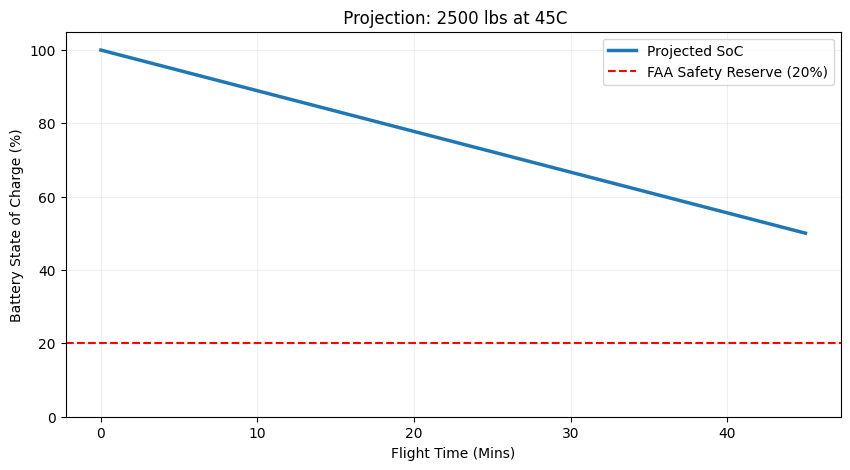

In [73]:
import matplotlib.pyplot as plt

# Generate time sequence based on our test duration
time_series = np.arange(0, d_min + 1) 
soc_curve = 100 - (burn_rate * time_series)

plt.figure(figsize=(10, 5))
plt.plot(time_series, soc_curve, label='Projected SoC', color='#1f77b4', linewidth=2.5)

# FAA Safety Threshold line
plt.axhline(y=commander.min_reserve_pct, color='red', linestyle='--', label='FAA Safety Reserve (20%)')

plt.title(f" Projection: {test_p} lbs at {test_t}C", fontsize=12)
plt.xlabel("Flight Time (Mins)")
plt.ylabel("Battery State of Charge (%)")
plt.ylim(0, 105)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()